# Extending Primitives with Stop Conditions

This example demonstrates how to use [stop conditions](https://doc.zahner.de/im7/apis/zahner_link/python/pages/stopconditions.html) to extend the behavior of primitive measurement jobs.

Specifically, we will perform a constant current charging of a 4700 µF capacitor. This is followed by an OCV (Open Circuit Voltage) scan, which continues until the rate of voltage change across the capacitor drops below a specified threshold, indicating it has relaxed.

This example also illustrates two different methods for determining the OCV of a device.

## Setup and Initialization

First, we import the necessary libraries, establish a connection to the IM7 potentiostat, configure the device, and select the potentiostat we want to use.

In [ ]:
import time
import sys
import zahner_link as zl
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter

link = zl.ZahnerLinkExc("10.10.253.154", "1994")

try:
    link.connect()
    print("connected successfully")
except zl.ZahnerLinkException as e:
    error_object: zl.ErrorObject = e.error    
    print(f"failed to connect, status: {error_object.get_error_code_enum()}, message: {error_object.get_message_formatted()}")
    sys.exit()

hardware_info_job = zl.control.GetHardwareInfoJob()
link.do_job(hardware_info_job)
hardware_info = hardware_info_job.get_job_result()

main_pot = None
for pot in hardware_info.potentiostats:
    print(
        f"found potentiostat: {pot.identifier} with serialnumber {pot.serialnumber} at {pot.url}"
    )
    if pot.identifier == "MAIN":
        main_pot = pot

config_for_main_pot = zl.HardwareSettingsHelper.get_config_for_main_potentiostat()
link.do_job(
    zl.control.SetHardwareSettingsJob(config=config_for_main_pot)
)

connected successfully
found potentiostat: MAIN with serialnumber 42176 at MAIN:1:POT


### Establishing Consistent Initial Conditions

This section can be skipped. Its purpose is to ensure the capacitor is in the same state at the beginning of each run, providing consistent results for the example.

In [21]:
switch_on_job = zl.control.SwitchOnJob(
    potentiostat=main_pot.url,
    coupling=zl.PotentiostatCoupling.POTENTIOSTATIC,
    bias=1.0, # 1 V
    voltage_range_index=0,
    compliance_range_index=0,
)
link.do_job(switch_on_job)
time.sleep(5)
link.do_job(zl.control.SwitchOffJob(potentiostat=main_pot.url))
time.sleep(5)

## Determining the OCV/OCP

There are two primary methods to determine the Open Circuit Voltage (OCV) of a device:

* Performing a scan using an [OcvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.OcvJob).
* Taking a single-point measurement of a channel using a [MeasureIntegralJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.MeasureIntegralJob) while the potentiostat is off.

In this example, we switch off the potentiostat before measuring. Note that switching off a potentiostat that is already off is safe and will not cause an error. However, attempting to switch on a potentiostat that is already active will result in an error.

We print both resulting OCV values to demonstrate that they are nearly identical.

The data from the OCV scan is stored in the `measurement_data` object.

In [22]:
link.do_job(zl.control.SwitchOffJob(potentiostat=main_pot.url))
ocv_scan = zl.meas.OcvJob(
    duration=10,
    output_data_rate=10,
)
link.do_job(ocv_scan)
measurement_data = link.get_job_result_data(ocv_scan)

ocv1 = measurement_data.get_dc_track("voltage")[-1]
print(f"OCV from OcvJob: {ocv1:.4f} V")

ocv_job = zl.control.MeasureIntegralJob(channel="voltage", duration=1)
link.do_job(ocv_job)
ocv2 = ocv_job.get_job_result()

print(f"OCV from MeasureIntegralJob: {ocv2:.4f} V")

OCV from OcvJob: 1.0115 V
OCV from MeasureIntegralJob: 1.0119 V


## Galvanostatic Charging to a Target Voltage

Next, we modify the parameters from the previous `switch_on_job` for galvanostatic charging. This is done by changing the coupling to galvanostatic and setting the bias to 0 A.

After switching on the potentiostat, we charge the capacitor using a galvanostatic [PogaJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.PogaJob). The measurement will run for a maximum of 60 seconds but will be terminated if the voltage reaches 2 V, as defined by the [MinMaxLimitStopCondition](https://doc.zahner.de/im7/apis/zahner_link/python/pages/stopconditions.html#zahner_link.meas.stop.MinMaxLimitStopCondition).

It is important to note that the stop conditions are checked at the interval of the `output_data_rate`. This rate must be set appropriately to ensure the measurement terminates promptly when the condition is met.

After the measurement, the new data is appended to the existing [DcDataset](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset) using the [append()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset.append) method.

In [ ]:
switch_on_job.parameters.coupling = zl.PotentiostatCoupling.GALVANOSTATIC
switch_on_job.parameters.bias = 0  # 0 A
link.do_job(switch_on_job)

cc_poga = zl.meas.PogaJob(
    bias=200e-6,  # 200 µA
    duration=60,
    output_data_rate=50,
    autorange=True,
    current_range=0.1,
    stop_conditions=[
        zl.meas.stop.MinMaxLimitStopCondition(
            for_dimension="voltage", minimum=0, maximum=2
        )
    ],
)
try:
    link.do_job(cc_poga)
except zl.ZahnerLinkException as e:
    error_object: zl.ErrorObject = e.error
    if error_object.get_error_code_enum() == zl.ErrorCodeEnum.STOP_CONDITION_TRIGGERED:
        print(f"successfully stopped on stop condition, error code: {error_object.get_error_code_enum()}, message: {error_object.get_message_formatted()}")
link.do_job(zl.control.SwitchOffJob(potentiostat=main_pot.url))

measurement_data.append(link.get_job_result_data(cc_poga))

successfully stopped on stop condition, error code: ErrorCodeEnum.STOP_CONDITION_TRIGGERED, message: stop condition #0 triggered: voltage: 2.00021 < 0 or 2.00021 > 2


True

The following code retrieves information about why the job was stopped, in this case due to the stop condition:

In [24]:
info = cc_poga.get_last_job_info()
error = info.get_error()

if error and error.get_error_code_enum() == zl.ErrorCodeEnum.STOP_CONDITION_TRIGGERED:
    print(f"Error code: {error.get_error_code_enum()}")
    print(error.get_message_formatted())
    print(error.get_message_format_string())
    print(error.get_message_parameters())
    #triggered_stop_condition = stop_conditions[error.get_message_parameters()[0]]
    #print(f"Triggered stop condition: {triggered_stop_condition}")

Error code: ErrorCodeEnum.STOP_CONDITION_TRIGGERED
stop condition #0 triggered: voltage: 2.00021 < 0 or 2.00021 > 2
stop condition #{0} triggered: {1}
[0, 'voltage: 2.00021 < 0 or 2.00021 > 2']


To find the exact stop condition, you should always pass a list of `stop_conditions`, as contained in the commented-out section.

## Waiting for the OCV to Relax

After charging, we use an [OcvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.OcvJob) with a [StabilityToleranceLimitStopCondition](https://doc.zahner.de/im7/apis/zahner_link/python/pages/stopconditions.html#zahner_link.meas.stop.StabilityToleranceLimitStopCondition) to wait for the OCV to stabilize. The measurement will stop when the rate of voltage change drops below 500 µV/s. The `minimum_time` parameter ensures the measurement runs for at least 10 seconds, while the job's `time` parameter sets a maximum duration of 60 seconds.

The data from this step is also appended to our dataset.

In [25]:
ocv_scan = zl.meas.OcvJob(
    duration=60,
    output_data_rate=10,
    stop_conditions=[
        zl.meas.stop.StabilityToleranceLimitStopCondition(
            for_dimension="voltage", stability_tolerance=0.0005, minimum_duration=10.0 # Stop when change is < 500 µV/s, run for at least 10s
        )
    ],
)
try:
    link.do_job(ocv_scan)
except zl.ZahnerLinkException as e:
    error_object: zl.ErrorObject = e.error
    if error_object.get_error_code_enum() == zl.ErrorCodeEnum.STOP_CONDITION_TRIGGERED:
        print(f"successfully stopped on stop condition, error code: {error_object.get_error_code_enum()}, message: {error_object.get_message_formatted()}")

measurement_data.append(link.get_job_result_data(ocv_scan))

successfully stopped on stop condition, error code: ErrorCodeEnum.STOP_CONDITION_TRIGGERED, message: stop condition #0 triggered: stability of voltage: 0.000487417 < 0.0005


True

## Save the Measurement Data in Zahner XML Format

To ensure complete measurement data integrity, the [HardwareInfo](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.HardwareInfo) should always be saved alongside the data, as demonstrated in the following example. You can retrieve this information from the device using [GetHardwareInfoJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.GetHardwareInfoJob).

In [26]:
xml_measurement = zl.xml.Measurement(hardware_info, measurement_data)

exporter = zl.xml.ZXmlExporter()
exporter.set_compact_xml(False)
exporter.save_as_file_standalone(
    xml_measurement,
    "charge.zmx"
)

0

## Plotting the Complete Data Set

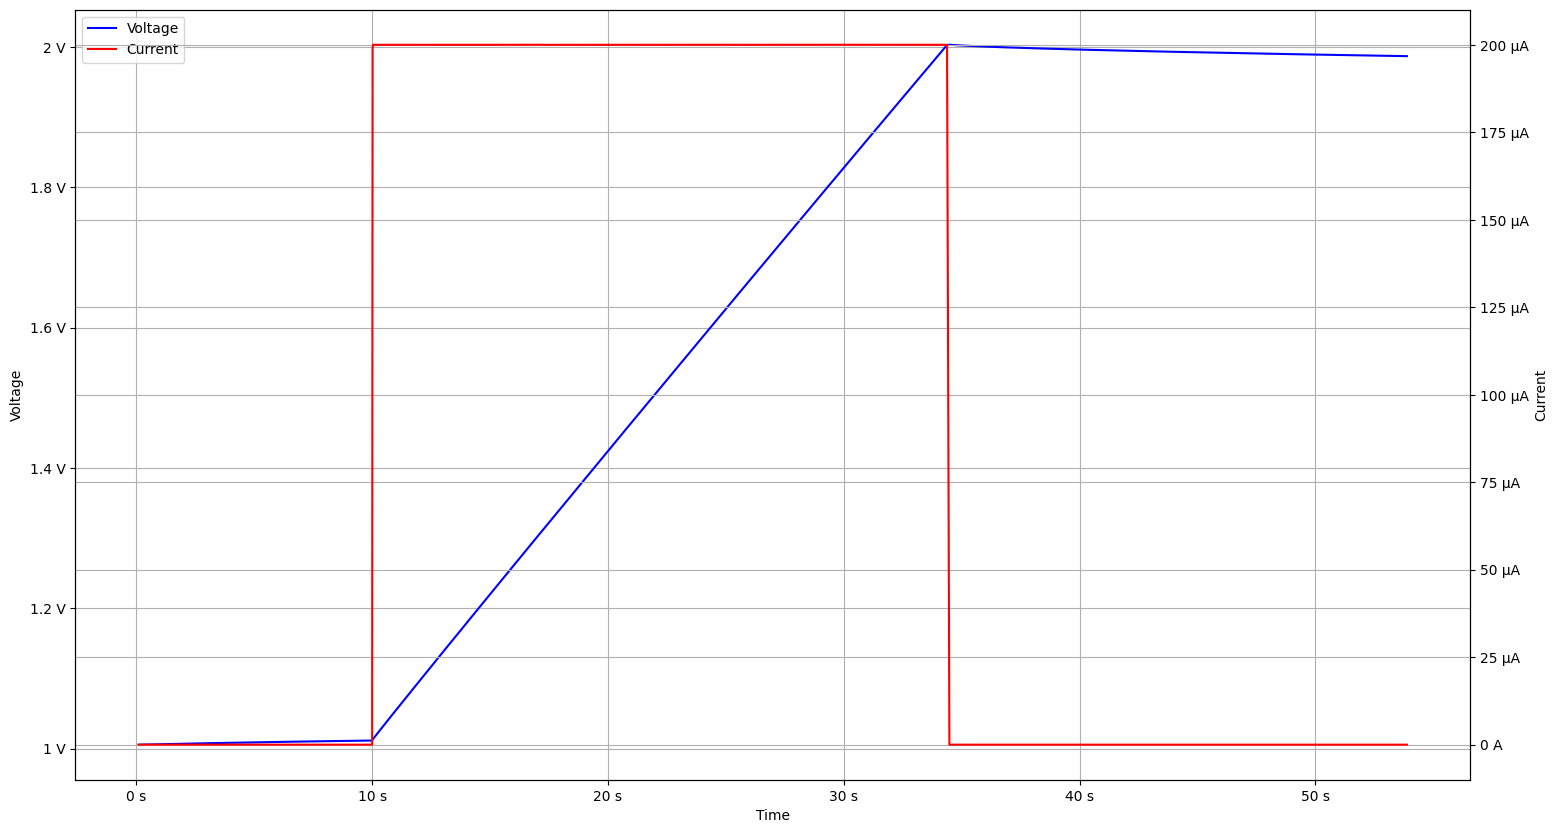

In [27]:
time = measurement_data.get_dc_track("time")
voltage = measurement_data.get_dc_track("voltage")
current = measurement_data.get_dc_track("current")

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
(line1,) = ax1.plot(time, voltage, color="blue", label="Voltage")
(line2,) = ax2.plot(time, current, color="red", label="Current")
ax1.legend(handles=[line1, line2])

ax1.xaxis.set_major_formatter(EngFormatter(unit="s"))
ax1.yaxis.set_major_formatter(EngFormatter(unit="V"))
ax1.set_xlabel("Time")
ax1.set_ylabel("Voltage")
ax1.grid(which="both")
ax2.xaxis.set_major_formatter(EngFormatter(unit="s"))
ax2.yaxis.set_major_formatter(EngFormatter(unit="A"))
ax2.set_xlabel("Time")
ax2.set_ylabel("Current")
ax2.grid(which="both")

fig.set_size_inches(18, 10)
plt.show()

In [28]:
link.disconnect()